# Section 1 - Repo setup & first exploration

**Project.** A binary classifier predicting whether a Bulgarian public-procurement
contract received only a **single bid** (`single_bid = (bids_received == 1)`) -
framed as a *competition red-flag indicator*, not a corruption detector. The unit
of analysis is the **contract**.

**Data.** ~193,161 contracts from the АОП/ЦАИС ЕОП open procurement register, via
SIGMA (sigma.midt.bg), licensed CC-BY 4.0, as of June 16, 2026.

**Goal of this notebook.** First contact with the raw data - shape, types, the
target's balance, and the distributions that shape later modelling decisions. No
cleaning or modelling yet; this is reconnaissance. Concretely:

1. Load `sigma-contracts.csv`, `sigma-authorities.csv` and `sigma-companies.csv`, then inspect their structure (`shape`, `head`, `info`).
2. Examine `bids_received` - the target's distribution and how much is missing.
3. Single-bid rate by `procedure` and `sector_code` - looking for patterns and
   traps (especially the procedure near-circularity).
4. The `value_eur` distribution - checking skew to justify a later log transform.

Findings and the decisions they imply are collected in the closing cell.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Notebook lives in notebooks/, data is one level up in data/
contracts = pd.read_csv("../data/raw/sigma-contracts.csv")
authorities = pd.read_csv("../data/raw/sigma-authorities.csv")
companies = pd.read_csv("../data/raw/sigma-companies.csv")

## 1. Load and inspect data structure

In [2]:
print(contracts.shape)
contracts.head()

(193161, 14)


,id,unp,subject,authority,authority_eik,contractor,contractor_eik,kind,sector_code,procedure,signed_at,value_eur,eu_funded,bids_received
0,e:00001-2021-0001:106742:_:eik:201472746:1,00001-2021-0001,Доставка и монтаж на каскадна инсталация от 6 ...,ИКОНОМИЧЕСКИ УНИВЕРСИТЕТ - ВАРНА,000083619,МЕГА ЕЛЕКТРОНИКС-АП ООД,201472746.0,company,42.0,Събиране на оферти,2021-07-16,32138.785068,0,3.0
1,e:00001-2021-0003:9643:_:eik:131468980:1,00001-2021-0003,Предоставяне на далекосъобщителна услуга чрез ...,ИКОНОМИЧЕСКИ УНИВЕРСИТЕТ - ВАРНА,000083619,"""А1 БЪЛГАРИЯ"" ЕАД",131468980.0,company,64.0,Събиране на оферти,2021-08-26,35789.920392,0,1.0
2,e:00001-2021-0006:15251:_:eik:103765686:1,00001-2021-0006,"Приготвяне, доставка на храна и осъществяване ...",ИКОНОМИЧЕСКИ УНИВЕРСИТЕТ - ВАРНА,000083619,ЗАЛИВА 47-СП АД,103765686.0,company,55.0,Пряко / без обявление,2021-10-11,409033.504957,0,3.0
3,e:00001-2021-0008:25147:_:eik:831079085:1,00001-2021-0008,„Снабдяване с природен газ за отопление на обе...,ИКОНОМИЧЕСКИ УНИВЕРСИТЕТ - ВАРНА,000083619,"""Примагаз"" АД",831079085.0,company,9.0,Пряко / без обявление,2021-12-15,76693.782179,0,1.0
4,e:00001-2021-0009:29019:_:eik:130533432:1,00001-2021-0009,„Снабдяване с природен газ за отопление на обе...,ИКОНОМИЧЕСКИ УНИВЕРСИТЕТ - ВАРНА,000083619,"""ОВЕРГАЗ МРЕЖИ"" АД",130533432.0,company,9.0,Пряко / без обявление,2022-01-19,255645.940598,0,1.0


In [3]:
contracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193161 entries, 0 to 193160
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              193161 non-null  object 
 1   unp             193161 non-null  object 
 2   subject         193161 non-null  object 
 3   authority       193161 non-null  object 
 4   authority_eik   193161 non-null  object 
 5   contractor      193161 non-null  object 
 6   contractor_eik  186407 non-null  float64
 7   kind            193161 non-null  object 
 8   sector_code     193156 non-null  float64
 9   procedure       193161 non-null  object 
 10  signed_at       193128 non-null  object 
 11  value_eur       193161 non-null  float64
 12  eu_funded       193161 non-null  int64  
 13  bids_received   174119 non-null  float64
dtypes: float64(4), int64(1), object(9)
memory usage: 20.6+ MB


In [4]:
print(authorities.shape)
authorities.head()

(4441, 9)


,eik,name,type_group,settlement,region,spent_eur,contracts,suppliers,avg_eur
0,000010756,"ДЕТСКА ГРАДИНА ""ЗДРАВЕЦ""",образование,гр.Сандански,Благоевград,3.755334e+05,10,5,37553
1,000010891,"НАЧАЛНО УЧИЛИЩЕ ""СВ.ПАИСИЙ ХИЛЕНДАРСКИ""",образование,NaN,NaN,5.650133e+04,1,1,56501
2,000010902,"ТРЕТО ОСНОВНО УЧИЛИЩЕ ""БРАТЯ МИЛАДИНОВИ""",образование,гр.Гоце Делчев,Благоевград,1.184543e+06,6,3,197424
3,000010927,"НАЧАЛНО УЧИЛИЩЕ ""ЯНЕ САНДАНСКИ""",образование,NaN,NaN,3.787701e+04,1,1,37877
4,000010934,"НАЧАЛНО УЧИЛИЩЕ ""СВ.СВ.КИРИЛ И МЕТОДИЙ""",образование,NaN,NaN,4.060869e+04,1,1,40609


In [5]:
authorities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4441 entries, 0 to 4440
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   eik         4441 non-null   object 
 1   name        4441 non-null   object 
 2   type_group  4441 non-null   object 
 3   settlement  2383 non-null   object 
 4   region      2355 non-null   object 
 5   spent_eur   4441 non-null   float64
 6   contracts   4441 non-null   int64  
 7   suppliers   4441 non-null   int64  
 8   avg_eur     4441 non-null   int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 312.4+ KB


In [6]:
print(companies.shape)
companies.head()

(17455, 8)


,eik,name,kind,settlement,won_eur,contracts,authorities,primary_sector
0,1.0,Elsevier B. V.,company,Барселона,4.574199e+07,14,3,72
1,2.0,инж. Владимир Станков,company,NaN,1.022584e+02,1,1,98
2,3.0,инж. Лъчезар Пиргов,company,NaN,4.090335e+02,1,1,98
3,3338.0,"Кооперация РАЙОННА ПОТРЕБИТЕЛНА КООПЕРАЦИЯ"" ПИ...",company,гр. Сандански,2.670637e+05,2,1,15
4,3361.0,"Кооперация ПОТРЕБИТЕЛНА КООПЕРАЦИЯ ""ПИРИН""",company,NaN,8.477083e+04,1,1,15


In [7]:
companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17455 entries, 0 to 17454
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   eik             12990 non-null  float64
 1   name            17455 non-null  object 
 2   kind            17455 non-null  object 
 3   settlement      4596 non-null   object 
 4   won_eur         17455 non-null  float64
 5   contracts       17455 non-null  int64  
 6   authorities     17455 non-null  int64  
 7   primary_sector  17455 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 1.1+ MB


## 2. The target: `bids_received` -> `single_bid`

The target is `single_bid = (bids_received == 1)`. Before defining it we look at
the raw bid-count distribution, including how many rows have no value at all, as
those rows can't be given a target.

In [8]:
# Full distribution of the bid count, INCLUDING missing (dropna=False).
contracts["bids_received"].value_counts(dropna=False).sort_index()

bids_received
0.0      2845
1.0     78158
2.0     32813
3.0     22206
4.0     12201
5.0      7173
6.0      4906
7.0      3091
8.0      2160
9.0      1670
10.0     1187
11.0      931
12.0      961
13.0      637
14.0      617
15.0      470
16.0      339
17.0      269
18.0      216
19.0      256
20.0       87
21.0      123
22.0       83
23.0      120
24.0       90
25.0       65
26.0       40
27.0       61
28.0       36
29.0        5
30.0       51
31.0       23
32.0        1
33.0       59
34.0       67
35.0        1
36.0        1
37.0        4
38.0        2
39.0        1
40.0       47
42.0       35
45.0        1
46.0        1
48.0        1
49.0        2
50.0        1
55.0        2
62.0        1
67.0        1
98.0        1
NaN     19042
Name: count, dtype: int64

In [9]:
# Separate the three quantities that drive our cleaning decisions in Section 2.
n_total   = len(contracts)
n_missing = contracts["bids_received"].isna().sum()
n_zero    = (contracts["bids_received"] == 0).sum()
n_known   = contracts["bids_received"].notna().sum()

print(f"total rows:                 {n_total:,}")
print(f"missing bid count:          {n_missing:,}  ({n_missing / n_total:.1%})")
print(f"zero-bid contracts:         {n_zero:,}  ({n_zero / n_total:.1%})")
print(f"rows with a KNOWN count:    {n_known:,}")

total rows:                 193,161
missing bid count:          19,042  (9.9%)
zero-bid contracts:         2,845  (1.5%)
rows with a KNOWN count:    174,119


**Why "known count" is the right denominator.** `single_bid` is only
meaningful where a bid count exists. If we compute `single_bid` on the full
frame, the 19k missing rows evaluate to `False` (because `NaN == 1` is `False`)
and silently join the negative class - which *dilutes every rate we report*.
So we build the target and measure its balance on the **known-count rows only**.

In [10]:
# Define the target, then measure balance on rows that actually have a count.
contracts["single_bid"] = contracts["bids_received"] == 1

known = contracts[contracts["bids_received"].notna()]
n_single = known["single_bid"].sum()
single_rate = known["single_bid"].mean()

print(f"single-bid contracts (known count): {n_single:,}")
print(f"single-bid rate (known count):      {single_rate:.4f}  (~{single_rate:.0%})")
print(f"=> class balance approx {single_rate:.0%} / {1 - single_rate:.0%} - well balanced")

single-bid contracts (known count): 78,158
single-bid rate (known count):      0.4489  (~45%)
=> class balance approx 45% / 55% - well balanced


## 3. Single-bid rate by `procedure` - spotting the near-circularity

In [11]:
# Single-bid rate by procedure, computed on known-count rows only.
# Columns: single_bid_rate (share), n_single_bid (count of single-bid),
# n_contracts (total in that procedure).
sb_by_procedure = (
    known.groupby("procedure")["single_bid"]
    .agg(single_bid_rate="mean", n_single_bid="sum", n_contracts="count")
    .sort_values("single_bid_rate", ascending=False)
)
sb_by_procedure["n_single_bid"] = sb_by_procedure["n_single_bid"].astype(int)
sb_by_procedure["single_bid_rate"] = sb_by_procedure["single_bid_rate"].round(3)
sb_by_procedure

,single_bid_rate,n_single_bid,n_contracts
procedure,,,
Друго,0.833,5,6
Пряко / без обявление,0.804,16854,20953
Неизвестна,0.550,6188,11254
Договаряне с покана,0.531,2486,4680
Събиране на оферти,0.416,14289,34372
Състезание,0.374,14183,37951
Открита,0.372,24153,64903


### EC-style single-bid indicator

The European Commission excludes **direct awards** from its "single bidder"
measure, because the rules for those procedures make no provision for competition
in the first place. The next cell approximates that by excluding the direct-award
procedure (`Пряко / без обявление`).

This is an **approximation** of the EC methodology, not an exact reproduction:

- the EC also excludes **framework agreements**, which this snapshot does not
  separately flag;
- the data still contains a negotiated procedure (`Договаряне с покана`) and an
  `Unknown` category that the EC might treat differently.

The direction is robust regardless - the rate stays far above the EC's "red"
threshold either way.

In [12]:
direct = "Пряко / без обявление"
ec_style = known[known["procedure"] != direct]
print(f"single-bid rate, all known-target rows:  {known['single_bid'].mean():.1%}")
print(f"EC-style (direct awards excluded):       {ec_style['single_bid'].mean():.1%}"
      f"  across {len(ec_style):,} contracts")
print(f"EC benchmark: green <=10%, red >20%")

single-bid rate, all known-target rows:  44.9%
EC-style (direct awards excluded):       40.0%  across 153,166 contracts
EC benchmark: green <=10%, red >20%


Direct awards sit far above every competitive procedure
(~0.80 vs ~0.37). That gap is the signal but for direct awards it is partly
definitional: the procedure means "awarded without an open call," so a single
bid is almost guaranteed. The feature `procedure` therefore carries near-circular
information about the label. Flagged here; investigated properly in Section 3
(model with and without it) and written up in Limitations.

In [13]:
# Robustness check on the "Неизвестна" (Unknown) procedure category.
# It is 11k+ rows with an above-average single-bid rate, so it is worth
# confirming these are not mislabelled direct awards quietly inflating the
# EC-style figure. If they behave like ordinary contracts, the headline holds.
unknown = "Неизвестна"
u = known[known["procedure"] == unknown]

print(f"Unknown-procedure rows:        {len(u):,}")
print(f"  single-bid rate:             {u['single_bid'].mean():.1%}")
print(f"  median value_eur:            {u['value_eur'].median():,.0f}  "
      f"(dataset median: {known['value_eur'].median():,.0f})")
print(f"  EU-funded share:             {u['eu_funded'].mean():.1%}")

# Does excluding Unknown (on top of direct awards) move the EC-style rate?
no_direct = known[known["procedure"] != direct]
no_direct_no_unknown = known[~known["procedure"].isin([direct, unknown])]
print(f"\nEC-style, direct excluded:           {no_direct['single_bid'].mean():.1%}")
print(f"EC-style, direct + Unknown excluded: {no_direct_no_unknown['single_bid'].mean():.1%}")
print("=> Unknown rows look like ordinary contracts (typical value, normal "
      "EU-funding);\n   removing them shifts the rate by ~1 point, so the "
      "headline figure is robust.")

Unknown-procedure rows:        11,254
  single-bid rate:             55.0%
  median value_eur:            24,520  (dataset median: 22,957)
  EU-funded share:             12.0%

EC-style, direct excluded:           40.0%
EC-style, direct + Unknown excluded: 38.8%
=> Unknown rows look like ordinary contracts (typical value, normal EU-funding);
   removing them shifts the rate by ~1 point, so the headline figure is robust.


In [14]:
# Is single-bid just a direct-award artefact? Check how many single-bid
# contracts remain if direct awards are removed entirely. If most survive,
# the pattern is real across competitive procedures, not just the circular one.
n_single = int(known["single_bid"].sum())
n_direct = int((known["procedure"] == direct).sum())
n_direct_single = int((known["single_bid"] & (known["procedure"] == direct)).sum())
n_single_nondirect = int((known["single_bid"] & (known["procedure"] != direct)).sum())

print(f"single-bid contracts, total:             {n_single:,}")
print(f"direct-award contracts:                  {n_direct:,}")
print(f"  of those, single-bid:                  {n_direct_single:,}"
      f"  ({n_direct_single / n_direct:.1%} of direct awards)")
print(f"single-bid contracts excluding direct:   {n_single_nondirect:,}"
      f"  ({n_single_nondirect / n_single:.1%} of all single-bid)")
print("=> single-bid is mostly NOT a direct-award artefact; the bulk sits in "
      "competitive procedures")

single-bid contracts, total:             78,158
direct-award contracts:                  20,953
  of those, single-bid:                  16,854  (80.4% of direct awards)
single-bid contracts excluding direct:   61,304  (78.4% of all single-bid)
=> single-bid is mostly NOT a direct-award artefact; the bulk sits in competitive procedures


## 4. Single-bid rate by `sector_code` (Common Procurement Vocabulary - CPV)

In [15]:
ref = pd.read_csv("../data/reference/cpv_sectors.csv")
labels_en = dict(zip(ref.sector_code, ref.label_en))

data_codes = set(known["sector_code"].astype(int).unique())
missing = sorted(data_codes - set(labels_en))
assert not missing, f"Codes in data absent from official CPV file: {missing}"

def sector_display(code):
    return f"{labels_en[int(code)]} ({int(code)})"

sector_summary = (
    known.groupby("sector_code")["single_bid"]
         .agg(single_bid_rate="mean", n_contracts="count")
         .sort_values("n_contracts", ascending=False)
)
sector_summary.index = sector_summary.index.map(sector_display)
sector_summary.head(20).round(3)

,single_bid_rate,n_contracts
sector_code,,
"Medical equipments, pharmaceuticals and personal care products (33)",0.422,31536
Construction work (45),0.374,24677
"Architectural, construction, engineering and inspection services (71)",0.354,12876
"Food, beverages, tobacco and related products (15)",0.300,10182
"Office and computing machinery, equipment and supplies except furniture and software packages (30)",0.362,9390
"Petroleum products, fuel, electricity and other sources of energy (9)",0.596,8825
Printed matter and related products (22),0.744,8796
Repair and maintenance services (50),0.550,8439
Transport equipment and auxiliary products to transportation (34),0.518,6255


## 5. `value_eur` - distribution and skew

In [16]:
# Summary statistics, plus the specific quantities the summary will cite.
print(contracts["value_eur"].describe())
print()
print(f"median:      {contracts['value_eur'].median():,.0f} EUR")
print(f"mean:        {contracts['value_eur'].mean():,.0f} EUR   (mean >> median => heavy tail)")
print(f"99th pctile: {contracts['value_eur'].quantile(0.99):,.0f} EUR")
print(f"max:         {contracts['value_eur'].max():,.0f} EUR")
print(f"exact zeros: {(contracts['value_eur'] == 0).sum():,}")
print(f"negatives:   {(contracts['value_eur'] < 0).sum():,}")
print(f"nulls:       {contracts['value_eur'].isna().sum():,}")

valid_values = contracts.loc[contracts["value_eur"].notna() & (contracts["value_eur"] >= 0), "value_eur"]

print(f"total value, valid only: {valid_values.sum():,.0f} EUR")

count    1.931610e+05
mean     2.672995e+05
std      4.767949e+06
min      0.000000e+00
25%      4.656846e+03
50%      2.300813e+04
75%      8.308493e+04
max      1.306710e+09
Name: value_eur, dtype: float64

median:      23,008 EUR
mean:        267,299 EUR   (mean >> median => heavy tail)
99th pctile: 3,703,160 EUR
max:         1,306,709,898 EUR
exact zeros: 205
negatives:   0
nulls:       0
total value, valid only: 51,631,829,243 EUR


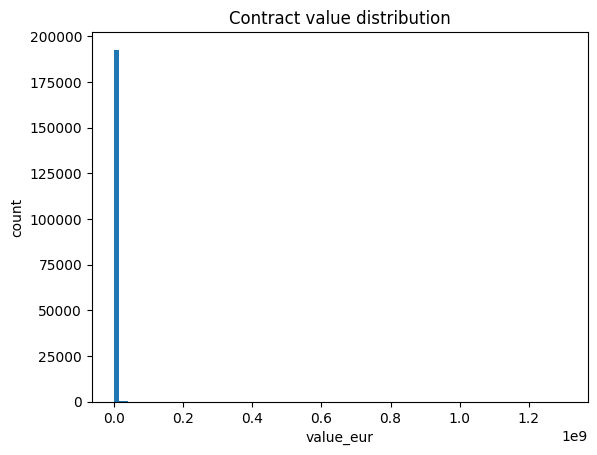

In [17]:
# Raw histogram - the skew is so strong the bars collapse into the left edge.
plt.hist(contracts["value_eur"], bins=100)
plt.xlabel("value_eur")
plt.ylabel("count")
plt.title("Contract value distribution")
plt.show()

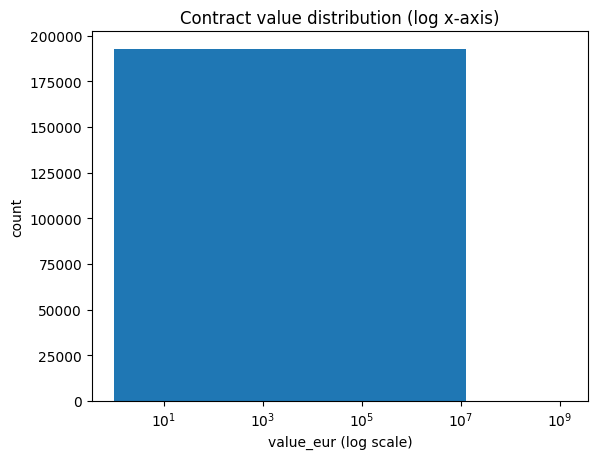

In [18]:
# Same data on a log x-axis: the distribution becomes readable (roughly
# log-normal). clip(lower=1) keeps the 205 zeros on the plot without log(0).
plt.hist(contracts["value_eur"].clip(lower=1), bins=100)
plt.xscale("log")
plt.xlabel("value_eur (log scale)")
plt.ylabel("count")
plt.title("Contract value distribution (log x-axis)")
plt.show()

The log-axis view is roughly bell-shaped - confirmation that a log
transform (handling the 205 zeros, e.g. `log1p`) will tame the skew before
modelling.

## 6. Data-quality check on `signed_at`

In [19]:
# Parse dates loosely and inspect the real span and null count.
signed = pd.to_datetime(contracts["signed_at"], errors="coerce")
print(f"earliest signed_at: {signed.min()}")
print(f"latest signed_at:   {signed.max()}")
print(f"unparseable/null:   {signed.isna().sum():,}")
print()
print("contracts per year:")
print(signed.dt.year.value_counts().sort_index().to_string())

earliest signed_at: 2009-06-01 00:00:00
latest signed_at:   2029-05-14 00:00:00
unparseable/null:   33

contracts per year:
signed_at
2009.0        1
2016.0        1
2019.0        1
2020.0     5753
2021.0    26426
2022.0    31421
2023.0    36392
2024.0    37326
2025.0    40626
2026.0    15180
2029.0        1


The span overruns the stated 2020–2026 window (stray earlier and
future-dated rows) and a few dates don't parse. Flagged for the date-feature step before deriving
`month` / `quarter` / `is_year_end`.

## Section 1 - findings & decisions

**Target (`single_bid = (bids_received == 1)`):**
- Out of **174,119** contracts that actually have a bid count, **78,158 (45%)**
  are single-bid. So the target is well balanced (~45/55) - no class-imbalance
  headache here. That said, precision/recall are still the better tools later,
  because for a flag like this accuracy alone doesn't really tell you much.
- `bids_received` is **missing for 19,042 rows (9.9%)**. Without a bid count there
  is no target to assign, so these get dropped in Section 2.
- **2,845 contracts (1.5%)** have `bids_received == 0`. With the `== 1` definition
  they're already negatives ("not single-bid"). Still an open question whether to
  drop them or leave them in the negative class - that gets decided and explained
  in Section 2.

**The main risk here - procedure near-circularity (this is the headline
limitation):**
- Looking only at rows with a known target, "Пряко / без обявление" (direct award)
  comes out at **80.4% single-bid across 20,953 contracts** - easily the highest
  of all procedures.
- The catch is that this procedure is basically **defined** as single-source. So
  for these rows the model isn't really predicting anything - it's more or less
  reading the answer off the label. Which means `procedure` carries this
  near-circular information.
- The spread itself is the interesting part: single-bid rate goes from ~37% for
  the open procedures ("Открита", "Състезание") up to ~80% for direct awards.
  Strong signal, but part of it is structural, not actual bidding behaviour.
- **Plan:** dig into this in Section 3 by running the models *with and without*
  `procedure` (and maybe dropping the direct-award rows too), then write it up in
  Limitations. The EC Single Market Scoreboard also handles direct awards
  separately, so there's solid cover if the examiner pushes on it.

**`value_eur` (no missing values, 205 exact zeros, no negatives):**
- Heavily right-skewed: **median ≈ 23k EUR** but **mean ≈ 267k**, 99th percentile
  ≈ 3.7M, and the max is ≈ 1.3bn EUR. The mean sitting ~10× above the median is a
  dead giveaway for a long tail.
- This is why a **log transform** makes sense before modelling (handling the 205
  zeros, e.g. with `log1p` or a small floor), otherwise a few giant contracts
  would basically run the show for the distance- and gradient-based models.

**Data-quality note for later:** `signed_at` isn't clean yet - once parsed, the
dates spill outside the assumed 2020–2026 window (a few older ones and even some
future dates), plus a handful that don't parse at all. Not fixing it here, just
flagging it for the date-feature step (Section 3/4).

**Next (Section 2):** deal with the missing bids, settle the zero-bid question,
and join authority `type_group` + `region` only - *not* the aggregate columns,
since those are a leakage risk.